# Hadronic fraction scan (KM3NeT) — Hands-on notebook
## Goal
This notebook simulates pseudo-data for a chosen source, runs a likelihood scan over the hadronic fraction **f**, and then aggregates many pseudo-experiments (seeds) to produce a median **ΔTS** curve with a credible band.


# What are we doing in this notebook?

In this notebook we perform a **likelihood scan** over a scaling parameter `f`
that multiplies the normalization of a physical model (e.g. a neutrino or gamma-ray component).

The workflow is:

1. Build a dataset (counts, exposure, IRFs)
2. Define a spectral model
3. Inject a signal with a given normalization
4. Scan over different model normalizations `f`
5. Compute the likelihood (or statistic) for each value of `f`
6. Build a ΔTS profile

The goal is to understand:
- which normalization is preferred by the data
- how strongly the data constrain the model
- how a prior affects the result


In [1]:
import os
import numpy as np
import astropy.units as u

from helpers import *  

## 1) User configuration
Adjust these values during the hands-on session. Everything else should run unchanged.

In [2]:
# Source / injection
SOURCE_NAME = 'Westerlund1'
SEED = 0
F_INJECTED = 1.0

# Dataset location (relative to this notebook)
DATASET_DIR = '../datasets/KM3NeT_Westerlund1_10y'
DATASETS_YAML = 'datasets.yaml'

# Scan grid
SCAN_VALUES = np.linspace(0.0, 1.0, 21)

# Prior settings
REL_PRIOR_ERR = 0.3

# Energy range for flux integral
E_INT_MIN = 0.1 * u.TeV
E_INT_MAX = 100 * u.TeV

# Output
OUT_FOLDER = f'results_f{F_INJECTED}p0'


## 2) Build models and datasets
This loads source metadata, Pion Decay (PD) model parameters, the KM3NeT datasets, and builds the SkyModel used in the scan.

In [3]:
source = load_source_list(SOURCE_NAME)
pars = load_pd_params_from_yaml(f'../models/{SOURCE_NAME}_model.yaml')
datasets = load_km3net_datasets(DATASET_DIR, DATASETS_YAML)

nu_model = build_hadronic_pd_model(source, pars, datasets.names)
nuisance = build_nuisance_prior(pars, rel_err=REL_PRIOR_ERR)

print(f"[INFO] Source: {source.name} | RA={source.position.ra.deg:.3f} deg | Dec={source.position.dec.deg:.3f} deg")
print(f"[INFO] Loaded {len(datasets)} KM3NeT sub-datasets")


/Users/adminlocal/Desktop/gammapy-acme/analysis/helpers.py:237: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(source_list_path, delim_whitespace=True, index_col=0, comment="#")


[INFO] Source: Westerlund1 | RA=251.767 deg | Dec=-45.851 deg
[INFO] Loaded 7 KM3NeT sub-datasets


## 3) Simulate pseudo-data (injection)
We inject a hadronic fraction **F_INJECTED** by scaling the model amplitude, attach the model to each dataset, and generate fake data with the chosen random seed.

# The statistical framework (what the fit is doing)

In Gammapy, each dataset defines a **likelihood** for the data given a model.  
Gammapy works in terms of a *statistic*:

$$
\mathrm{stat}(\theta) \equiv -2\,\ln \mathcal{L}(\theta) + \text{const}
$$

where $\theta$ are the model parameters (spectral parameters, background nuisance parameters, …).  
A fit means **minimizing** this statistic.

---

## What parameters are we fitting?

In this notebook we build a neutrino *hadronic* model (p–p $\rightarrow$ $\pi$ $\rightarrow$ $\nu$)  
and then we scan a **hadronic fraction** $f$ that scales the model amplitude.

At each scan point $f_i$:

1. We set the model amplitude to the value corresponding to $f_i$
2. We **optimize the other free parameters** (e.g. shape parameters like $\alpha$, $\beta$, $E_\mathrm{cut}$, if not frozen)
3. We record the best-fit statistic

This is a **profile likelihood**: for every $f$, you minimize over the nuisance parameters.

---

## Priors as penalty terms (MAP instead of pure ML)

For hands-on purposes we include simple Gaussian “priors” (implemented as a penalty term added to the stat):

$$
\mathrm{stat}_\mathrm{tot}(\theta)
=
\mathrm{stat}_\mathrm{data}(\theta)
+
\sum_k \left( \frac{\theta_k - \theta_{k,0}}{\sigma_k} \right)^2
$$

That’s equivalent to a **maximum a-posteriori (MAP)** estimate with Gaussian priors.  
In the code, this is handled by `PriorDatasets.stat_sum()`.

---

## Test statistic and $\Delta$TS curve

From the scan we compute:

$$
\Delta \mathrm{TS}(f) = \mathrm{stat}(f) - \min_f \mathrm{stat}(f)
$$

- The minimum corresponds to the best-fit $f$.  
- The curvature near the minimum relates to the uncertainty on $f$.  
- Under regular conditions, Wilks’ theorem suggests $\Delta\mathrm{TS}$ behaves roughly like a $\chi^2$  
  with 1 degree of freedom when scanning one parameter — but **this is an approximation**,  
  and boundaries (like $f \ge 0$) can change the behavior.

In [4]:
cwd = os.getcwd()
os.chdir('../datasets/KM3NeT_Westerlund1_10y')
fit_model_to_fake_data(datasets, nu_model, f_injected=F_INJECTED, seed=SEED)
print(f"[INFO] Pseudo-data generated for f={F_INJECTED} (seed={SEED})")


HDU 'MASK_FIT' not found
HDU 'MASK_FIT' not found
HDU 'MASK_FIT' not found
HDU 'MASK_FIT' not found
HDU 'MASK_FIT' not found
HDU 'MASK_FIT' not found
HDU 'MASK_FIT' not found


[INFO] Pseudo-data generated for f=1.0 (seed=0)


## 4) Likelihood scan over f
For each f on the scan grid we:
- set the amplitude prior mean to `f * amplitude(f=1)`
- store TS (with and without prior) and the integrated flux


# What is a likelihood scan?

A *likelihood scan* evaluates the best-fit likelihood **as a function of one chosen parameter** (here: the hadronic fraction \(f\)).

At each scan point:
- set \(f\)
- **fit** (minimize the stat) over the other free parameters
- store the best-fit stat (optionally with prior penalty terms)

This is a classic way to:
- visualize degeneracies among parameters,
- estimate uncertainties (via \(\Delta\mathrm{TS}\)),
- and build pseudo-experiment ensembles (many seeds) to understand coverage / sensitivity.

Practical note for hands-on sessions: a full scan can take hours/days.
So below we support two modes:

1. **Fast mode (default):** load precomputed scan results from disk.
2. **Compute mode:** run the scan (optionally with a coarse grid).


In [9]:
import time
from pathlib import Path

# -----------------------------
# 4) Likelihood scan over f
# -----------------------------
# Hands-on default: load cached results (fast).
RUN_SCAN = False  # set True if you *really* want to run the optimizer

# Scan grid (coarse by default for speed)
f_scan = np.linspace(0.0, 1.0, 11)

# Energy integration range for neutrino flux
e_int_min = E_INT_MIN
e_int_max = E_INT_MAX

# Where results are saved / loaded
out_dir = Path(OUT_FOLDER) / f"results_f{str(F_INJECTED).replace('.', 'p')}"
out_dir.mkdir(parents=True, exist_ok=True)

def _find_cached_file(seed: int) -> Path | None:
    # expected naming: results_f<ftag>_s<seed>.npy inside out_dir
    ftag = str(F_INJECTED).replace('.', 'p')
    cand = out_dir / f"results_f{ftag}_s{seed}.npy"
    return cand if cand.exists() else None

cached = _find_cached_file(SEED)

if (not RUN_SCAN) and (cached is not None):
    print(f"[INFO] Loading cached scan: {cached}")
    res = np.load(cached, allow_pickle=True).item()

elif (not RUN_SCAN) and (cached is None):
    print("[WARN] No cached file found for this seed.")
    print("       Falling back to a *very fast* scan without optimization (no fit).")
    print("       This is useful to illustrate what is being scanned, but it is NOT the real profile likelihood.")
    res = run_likelihood_scan_no_opt(
        datasets=datasets,
        model=nu_model,
        nuisance=nuisance,
        scan_values=f_scan,
        e_int_min=e_int_min,
        e_int_max=e_int_max,
        rel_err=REL_PRIOR_ERR,
    )

else:
    print("[INFO] Running the full likelihood scan (this can be slow).")
    t0 = time.time()
    res = run_likelihood_scan(
        datasets=datasets,
        model=nu_model,
        nuisance=nuisance,
        scan_values=f_scan,
        e_int_min=e_int_min,
        e_int_max=e_int_max,
        rel_err=REL_PRIOR_ERR,
        warm_start=True,
        restore_before_first_fit=True,
    )
    dt = time.time() - t0
    print(f"[INFO] Scan completed in {dt:.1f} s")

    save_scan_results(res, OUT_FOLDER, f_input=F_INJECTED, seed=SEED)

# Remove priors for later cells unless explicitly needed
datasets.nuisance = None

[WARN] No cached file found for this seed.
       Falling back to a *very fast* scan without optimization (no fit).
       This is useful to illustrate what is being scanned, but it is NOT the real profile likelihood.


[INFO] Using no-prior stat (fast mode). Set RUN_SCAN=True to get the profile likelihood with priors.
Best-fit f ≈ 1.000
ΔTS grid: [29.494 17.995 13.541 10.479  8.12   6.201  4.589  3.206  2.002  0.942
  0.   ]


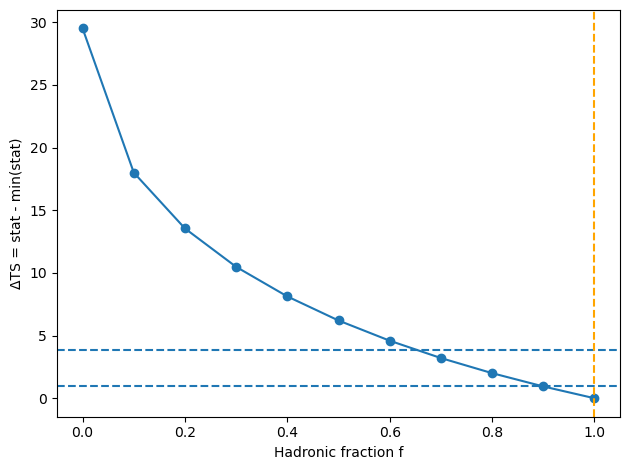

Rule of thumb (Wilks, 1 dof): ΔTS≈1 ~ 1σ, ΔTS≈3.84 ~ 95% CL (approx; boundaries can matter).


In [10]:
# EXERCISE: turn stats into ΔTS and estimate the best-fit f
stat_use = res.get("stat_with_prior", None)
if stat_use is None or np.all(np.isnan(stat_use)):
    print("[INFO] Using no-prior stat (fast mode). Set RUN_SCAN=True to get the profile likelihood with priors.")
    stat_use = res["stat"]

delta_ts = stat_use - np.nanmin(stat_use)
f_best = float(res["values"][np.nanargmin(stat_use)])

print(f"Best-fit f ≈ {f_best:.3f}")
print("ΔTS grid:", np.round(delta_ts, 3))

# Quick plot
import matplotlib.pyplot as plt
plt.figure()
plt.plot(res["values"], delta_ts, marker="o")
plt.axhline(1.0, linestyle="--")
plt.axhline(3.84, linestyle="--")
plt.axvline(1, linestyle="--", color ='orange')

plt.xlabel("Hadronic fraction f")
plt.ylabel("ΔTS = stat - min(stat)")
plt.tight_layout()
plt.show()

print("Rule of thumb (Wilks, 1 dof): ΔTS≈1 ~ 1σ, ΔTS≈3.84 ~ 95% CL (approx; boundaries can matter).")


## 5) Aggregate many seeds and plot ΔTS
This section reads all `results_f{F_INJECTED}_s*.npy` files in the output folder and produces:
- median ΔTS across seeds
- central credible band (percentile-based) for the chosen confidence level


results_f1.0p0
[INFO] Found 99 .npy files in results_f1.0p0


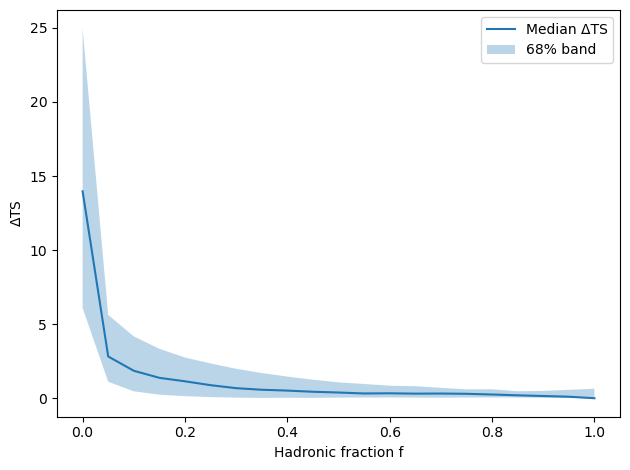

In [11]:
import matplotlib.pyplot as plt
os.chdir(cwd)
CONFIDENCE_LEVEL = 0.68

# NOTE: results are stored inside `OUT_FOLDER/results_f<ftag>/`
results_dir = Path(OUT_FOLDER) #/ f"results_f{str(F_INJECTED).replace('.', 'p')}"
files, data = load_scan_files(results_dir, f_input=F_INJECTED, verbose=True)
print(results_dir)
print(f"[INFO] Found {len(files)} .npy files in {results_dir}")

# Be tolerant: if filename convention differs, try loading all result files in the folder
if len(data) == 0:
    files2, data2 = load_scan_files(results_dir, f_input=None, verbose=True)
    if len(data2) > 0:
        files, data = files2, data2
        print(f"[INFO] Loaded {len(data)} valid result dicts after fallback (loading all patterns).")

if len(data) == 0:
    print("[WARN] I can see .npy files, but none could be parsed as result dictionaries.")
    print("       This usually means the files were produced by an older/different format.")
    print("       First few files found:")
    for fn in files[:10]:
        print("   -", fn.name)
else:
    f_values = data[0]["values"]
    all_delta = np.array([delta_ts_from_stat_with_prior(d["stat_with_prior"]) for d in data])
    median, lo, hi = median_and_credible_band(all_delta, confidence_level=CONFIDENCE_LEVEL)

    plt.figure()
    plt.plot(f_values, median, label="Median ΔTS")
    plt.fill_between(f_values, lo, hi, alpha=0.3, label=f"{int(CONFIDENCE_LEVEL*100)}% band")
    plt.xlabel("Hadronic fraction f")
    plt.ylabel(r"$\Delta \mathrm{TS}$")
    plt.legend()
    plt.tight_layout()
    plt.show()
